<a href="https://colab.research.google.com/github/gautamkr1876/AIML_ClassNotes/blob/main/7.%20Advanced%20AI%20Agents/10.%20Model%20Quantization%20Techniques%20-2/v3_Class_Ref_Model_Quantization.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Model Quantization — Best Practices, End to End

**A 3.5-hour hands-on class.** One case study, one real dataset, one scorecard — and every major quantization idea measured on a model you train yourself in the first ten minutes.

---

## The case study: *Cairn* must ship

**Trailhead Outfitters** runs 400 stores selling hiking and camping gear. Every store has a self-service kiosk running **Cairn**, an assistant that reads what a customer types —

> *"can you help me return these boots"* · *"do you have this jacket in medium"* · *"what time do you close"*

— and routes it to one of **150 intents** (returns, stock lookup, store hours, card payments, …). The routing brain is a small BERT classifier. It works great on the data-science team's laptops.

The problem is the fleet:

| | The dev box (this Mac) | The kiosk box (the target) |
|---|---|---|
| CPU | M3 Max, 16 cores | quad-core ARM, fanless |
| RAM | 128 GB | 4 GB |
| GPU | yes (MPS) | none |
| Network | fast | store DSL, shared, nightly update window |

Ops has given us hard **budgets** before Cairn v1.1 can roll out:

| Budget | Target | Why |
|---|---|---|
| **B1 — artifact size** | **≤ 12 MB** | nightly over-the-air update across 400 stores |
| **B2 — accuracy** | **≥ 84%** intent accuracy on the held-out test set | ops' routing-quality floor (fp32 lands ~90%, so at most ~6 points may be sacrificed) |
| **B3 — latency** | ≤ 30 ms per utterance on CPU, and no regression worse than 2× vs fp32 | conversational feel |
| **B4 — roadmap** | leave RAM headroom for **Cairn v2**: an on-device 1.1B-parameter chat LLM | Part 9 |

Our fp32 model is **~45 MB** — nearly 4× over budget B1 before we even start. Everything in this class is a step toward closing that gap *without giving up B2*, and every step lands as a row on a shared **scorecard**.

**The dataset is real:** [CLINC150](https://github.com/clinc/oos-eval) — 22,500 crowd-sourced utterances collected specifically to train intent systems for virtual assistants (150 intents × 100 training examples each, plus validation and test splits). Exactly Cairn's job.

---

## The road map

```
                      THE ROAD TO SHIPPING CAIRN
              (every part ends with a scorecard update)

 [P0 Setup] -> [P1 Baseline: Cairn in fp32]
                  |   45 MB, ~90% accuracy  ->  FAILS the 12 MB budget
                  v
 [P2 Inside the numbers]     sign | exponent | mantissa
                  |   fp32 -> fp16/bf16: half the bytes, accuracy free
                  |   ... but 22 MB is still not 12 MB, and int8 has NO exponent
                  v
 [P3 The int8 map]          scale & zero-point, symmetric vs asymmetric
                  v
 [P4 Granularity]           per-tensor / per-channel / per-group
                  |            (the int4 rescue: same bits, +18 points)
                  v
 [P5 Calibration]           choosing activation ranges: run a little real
                  |            traffic, write down each layer's lo/hi
                  v
 [P6 PTQ: the ship candidate]   assemble the recipe, run REAL backends,
                  |             pack a real file  ->  ~11 MB  PASS
                  v
 [P7 The bit ladder]        how low can post-training quantization go?
                  |            int4 ok (with care) . int3 leaks . int2 collapses
                  v
 [P8 QAT]                   train WITH the quantizer in the loop:
                  |            int2 comes back from the dead
                  v
 [P9 Cairn v2: the LLM world]   TinyLlama on this laptop, and the map to
                                GGUF / GPTQ / AWQ / bnb / FP8 / MXFP4 / QAT
```

**Ground rules for every experiment in this notebook**

1. **One eval protocol.** All comparisons use the same fixed validation set (3,000 utterances). The test set (4,500) is touched exactly once, at the very end, for the shipping decision.
2. **Measure, don't assume.** Size, accuracy, and latency are measured live. Some results will *contradict* popular tutorials — those are the best parts.
3. **Small code, on purpose.** Every technique here is a handful of lines of plain PyTorch — two ten-line wrapper classes are as fancy as this notebook gets. If you can read a `for` loop, you can read everything in it.
4. **Runs offline.** After the one-time download cell, no network and no API keys are needed.

*(Environment: Python 3.12 · torch 2.10 · transformers 5.5 · Apple Silicon with MPS. Training cells take seconds, not minutes; the whole notebook runs top-to-bottom in ~10 minutes.)*

```
 P0     P1     P2     P3     P4     P5     P6     P7     P8     P9
 setup  base   bits   map    grain  calib  PTQ    ladder QAT    LLM
 ^^^^^
 YOU ARE HERE - Part 0: Setup & sanity checks               (~10 min)
```

# Part 0 — Setup

Imports, seeds, plot styling, and a one-time download cell (the dataset comes from GitHub, the pre-trained backbone from the Hugging Face hub — both fetched with `curl` so the cell also works behind VPNs that break Python's downloaders).

In [1]:
import os, json, time, copy, struct, warnings, subprocess
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import transformers

warnings.filterwarnings("ignore")                    # we re-enable one warning on purpose in Part 6
transformers.logging.set_verbosity_error()
transformers.logging.disable_progress_bar()

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"   # train/eval fast on the dev box
torch.backends.quantized.engine = "qnnpack"                      # int8 kernels for ARM CPUs

# one small, consistent set of plot colors for the whole class
C_BLUE, C_GREEN, C_MAGENTA, C_YELLOW = "#2a78d6", "#008300", "#e87ba4", "#eda100"
C_INK, C_SUBTLE, C_MUTED, C_GRID, C_AXIS = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
C_GOOD, C_BAD = "#0ca30c", "#d03b3b"     # reserved for pass/fail, always with a text label
plt.rcParams.update({
    "figure.figsize": (7.5, 4), "figure.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": C_AXIS, "axes.labelcolor": C_SUBTLE,
    "axes.titlecolor": C_INK, "axes.titlesize": 11, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C_GRID, "grid.linewidth": 0.8,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "lines.linewidth": 2,
})

print("torch       :", torch.__version__)
print("transformers:", transformers.__version__)
print("device      :", DEVICE, "| quantized engine:", torch.backends.quantized.engine)

torch       : 2.10.0
transformers: 5.5.4
device      : mps | quantized engine: qnnpack


In [2]:
# ---- one-time downloads (skipped when the files already exist) ----
os.makedirs("data", exist_ok=True); os.makedirs("models/bert-mini", exist_ok=True)

def fetch(url, dest, min_bytes=100):
    if os.path.exists(dest) and os.path.getsize(dest) > min_bytes:
        print(f"[cached]     {dest}")
        return
    subprocess.run(["curl", "-sL", "--max-time", "300", "-o", dest, url], check=True)
    print(f"[downloaded] {dest}  ({os.path.getsize(dest)/1e6:.1f} MB)")

# CLINC150: 22.5k real utterances for exactly Cairn's task (intent routing)
fetch("https://raw.githubusercontent.com/clinc/oos-eval/master/data/data_full.json",
      "data/clinc150.json")

# bert-mini: a 4-layer, 256-hidden BERT pre-trained by Google, re-hosted by prajjwal1
for f in ["pytorch_model.bin", "config.json", "vocab.txt"]:
    fetch(f"https://huggingface.co/prajjwal1/bert-mini/resolve/main/{f}", f"models/bert-mini/{f}")

# The hub copy of bert-mini predates today's transformers: its config.json lacks
# `model_type`, and it ships no tokenizer_config.json (without one, building a
# tokenizer straight from vocab.txt silently maps every word to [UNK] - we learned
# this the hard way). Patch both once so from_pretrained() just works.
cfg = json.load(open("models/bert-mini/config.json"))
if cfg.get("model_type") != "bert":
    cfg["model_type"] = "bert"
    json.dump(cfg, open("models/bert-mini/config.json", "w"), indent=1)
tok_cfg = "models/bert-mini/tokenizer_config.json"
if not os.path.exists(tok_cfg):
    json.dump({"tokenizer_class": "BertTokenizer", "do_lower_case": True,
               "model_max_length": 512}, open(tok_cfg, "w"), indent=1)
print("checkpoint ready")

[cached]     data/clinc150.json
[cached]     models/bert-mini/pytorch_model.bin
[cached]     models/bert-mini/config.json
[cached]     models/bert-mini/vocab.txt
checkpoint ready


In [3]:
# ---- first look at the data Cairn lives on ----
raw = json.load(open("data/clinc150.json"))
for split in ["train", "val", "test"]:
    print(f"{split:5s}: {len(raw[split]):6,d} utterances")

INTENTS = sorted({label for _, label in raw["train"]})
print(f"intents: {len(INTENTS)}  e.g. {INTENTS[:4]} ... {INTENTS[-2:]}")

pd.DataFrame(raw["train"][::2500], columns=["utterance", "intent"])

train: 15,000 utterances
val  :  3,000 utterances
test :  4,500 utterances
intents: 150  e.g. ['accept_reservations', 'account_blocked', 'alarm', 'application_status'] ... ['who_made_you', 'yes']


,utterance,intent
0,what expression would i use to say i love you ...,translate
1,savings account balance at chase bank please,balance
2,tell me my reminders,reminder
3,use a different accent,change_accent
4,tell me when my car last had its oil changed,last_maintenance
5,what's the cheapest fares from lax to sfo for ...,book_flight


Real people, real phrasing, real typos — this is the traffic Cairn sees. (The dataset also ships an `oos_*` split of *out-of-scope* queries for training rejection behaviour; that is a different class — today we focus on the 150 in-scope intents.)

---

```
 P0     P1     P2     P3     P4     P5     P6     P7     P8     P9
 setup  base   bits   map    grain  calib  PTQ    ladder QAT    LLM
        ^^^^^
        YOU ARE HERE - Part 1: the fp32 baseline            (~25 min)
```

# Part 1 — Meet the workload: Cairn in fp32

Before we compress anything we need the thing we'll be protecting: a trained model and its **baseline numbers**. The plan:

1. tokenize the utterances,
2. fine-tune a small pre-trained BERT (**bert-mini**: 4 layers, hidden size 256, ~11M parameters) as the intent classifier,
3. measure the three quantities every quantization decision trades between — **accuracy, size, latency**,
4. find out *where the bytes actually live* in this model (the answer will steer the whole class).

> **Why a small model?** Because the kiosk box is small — and because an 11M-parameter model trains in ~20 seconds on this laptop, which means every experiment today runs on a model *you* trained, not screenshots of someone else's. Every technique scales up unchanged; Part 9 applies the same code to a 1.1B-parameter LLM.

In [4]:
from transformers import AutoTokenizer, BertForSequenceClassification, BertConfig

tokenizer = AutoTokenizer.from_pretrained("models/bert-mini")
lab2id = {label: i for i, label in enumerate(INTENTS)}

def encode(rows, max_length=32):
    enc = tokenizer([text for text, _ in rows], padding="max_length", truncation=True, max_length=max_length, return_tensors="pt")
    labels = torch.tensor([lab2id[label] for _, label in rows])
    return enc["input_ids"], enc["attention_mask"], labels

X_train, M_train, Y_train = encode(raw["train"])
X_val,   M_val,   Y_val   = encode(raw["val"])
X_test,  M_test,  Y_test  = encode(raw["test"])

print("train tensors:", tuple(X_train.shape))
print("a sample, decoded back:", tokenizer.decode(X_train[0][:14]))

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0).
W0716 20:40:59.287000 69242 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


train tensors: (15000, 32)
a sample, decoded back: [CLS] what expression would i use to say i love you if i were


In [5]:
# bert-mini ships as a pre-trained *backbone*; the 150-way classifier head is new (random)
config = BertConfig.from_pretrained("models/bert-mini", num_labels=len(INTENTS))
model = BertForSequenceClassification(config) # this basically adds a new classification head on top of the pre-trained backbone

backbone = torch.load("models/bert-mini/pytorch_model.bin", weights_only=True)

for k, v in backbone.items():
	print(k, v.shape)

bert.embeddings.position_ids torch.Size([1, 512])
bert.embeddings.word_embeddings.weight torch.Size([30522, 256])
bert.embeddings.position_embeddings.weight torch.Size([512, 256])
bert.embeddings.token_type_embeddings.weight torch.Size([2, 256])
bert.embeddings.LayerNorm.weight torch.Size([256])
bert.embeddings.LayerNorm.bias torch.Size([256])
bert.encoder.layer.0.attention.self.query.weight torch.Size([256, 256])
bert.encoder.layer.0.attention.self.query.bias torch.Size([256])
bert.encoder.layer.0.attention.self.key.weight torch.Size([256, 256])
bert.encoder.layer.0.attention.self.key.bias torch.Size([256])
bert.encoder.layer.0.attention.self.value.weight torch.Size([256, 256])
bert.encoder.layer.0.attention.self.value.bias torch.Size([256])
bert.encoder.layer.0.attention.output.dense.weight torch.Size([256, 256])
bert.encoder.layer.0.attention.output.dense.bias torch.Size([256])
bert.encoder.layer.0.attention.output.LayerNorm.weight torch.Size([256])
bert.encoder.layer.0.attention.ou

In [6]:
model

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 256, padding_idx=0)
      (position_embeddings): Embedding(512, 256)
      (token_type_embeddings): Embedding(2, 256)
      (LayerNorm): LayerNorm((256,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=256, out_features=256, bias=True)
              (key): Linear(in_features=256, out_features=256, bias=True)
              (value): Linear(in_features=256, out_features=256, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=256, out_features=256, bias=True)
              (LayerNorm): LayerNorm((256,), eps=1e-12, e

In [7]:

result = model.bert.load_state_dict({k[len("bert."):]: v for k, v in backbone.items() if k.startswith("bert.")}, strict=False)



print("backbone loaded | missing:", result.missing_keys, "| unexpected:", result.unexpected_keys)

n_params = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_params/1e6:.1f}M  ->  fp32 = {n_params*4/1e6:.1f} MB   (budget B1 is 12 MB)")

backbone loaded | missing: [] | unexpected: ['embeddings.position_ids']
parameters: 11.2M  ->  fp32 = 44.8 MB   (budget B1 is 12 MB)


### Three measuring instruments, used in every part

Read them once, then trust them for the rest of the day:

- `evaluate(model, split)` — accuracy on the **fixed** val (or, once, test) split. Same data every time, so numbers are comparable across all of today's experiments.
- `latency_ms(model)` — median per-utterance CPU latency, batch size 1 (that's how a kiosk sees traffic), 4 threads (that's the kiosk's core count).
- `size_mb(state_dict)` — actual serialized bytes, by saving to disk and reading the file size. No theoretical estimates.

In [8]:
SPLITS = {"val": (X_val, M_val, Y_val), "test": (X_test, M_test, Y_test)}

def evaluate(m, split="val", batch_size=512, device=DEVICE):
    X, M, Y = SPLITS[split]
    m = m.eval().to(device)
    correct = 0
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            logits = m(input_ids=X[i:i+batch_size].to(device),
                       attention_mask=M[i:i+batch_size].to(device)).logits
            correct += (logits.argmax(-1).cpu() == Y[i:i+batch_size]).sum().item()
    m.to("cpu")
    return correct / len(X)

def latency_ms(m, iters=100, warmup=20, threads=4):
    m = m.eval().to("cpu")
    x, a = X_val[:1], M_val[:1]
    old = torch.get_num_threads(); torch.set_num_threads(threads)
    times = []
    with torch.no_grad():
        for _ in range(warmup): m(input_ids=x, attention_mask=a)
        for _ in range(iters):
            t = time.perf_counter(); m(input_ids=x, attention_mask=a)
            times.append((time.perf_counter() - t) * 1000)
    torch.set_num_threads(old)
    return float(np.median(times))

def size_mb(state_dict, path="models/_tmp_size_probe.pt"):
    torch.save(state_dict, path)
    mb = os.path.getsize(path) / 1e6
    os.remove(path)
    return mb

print("instruments ready")

instruments ready


In [9]:
# ---- fine-tune Cairn (5 epochs; ~20s on MPS) ----
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
BATCH, EPOCHS = 64, 10
model.to(DEVICE)

t0 = time.time()
for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(len(X_train))
    losses = []
    for i in range(0, len(X_train), BATCH):
        idx = perm[i:i+BATCH]
        out = model(input_ids=X_train[idx].to(DEVICE), attention_mask=M_train[idx].to(DEVICE),labels=Y_train[idx].to(DEVICE))
        out.loss.backward(); optimizer.step(); optimizer.zero_grad()
        losses.append(out.loss.item())
    val_acc = evaluate(model); model.to(DEVICE)
    print(f"epoch {epoch+1}/{EPOCHS}  train_loss={np.mean(losses):.3f}  val_acc={val_acc:.1%}")
print(f"total: {time.time()-t0:.0f}s")

model = model.to("cpu")
torch.save(model.state_dict(), "models/cairn_fp32.pt")

epoch 1/10  train_loss=4.274  val_acc=63.9%
epoch 2/10  train_loss=2.580  val_acc=79.6%
epoch 3/10  train_loss=1.411  val_acc=85.4%
epoch 4/10  train_loss=0.799  val_acc=90.0%
epoch 5/10  train_loss=0.477  val_acc=91.1%
epoch 6/10  train_loss=0.308  val_acc=92.6%
epoch 7/10  train_loss=0.203  val_acc=92.7%
epoch 8/10  train_loss=0.142  val_acc=93.3%
epoch 9/10  train_loss=0.103  val_acc=93.3%
epoch 10/10  train_loss=0.078  val_acc=93.5%
total: 38s


In [10]:
# ---- the three baseline numbers every later experiment answers to ----
FP32_VAL = evaluate(model, "val")
FP32_MB  = size_mb(model.state_dict())
FP32_MS  = latency_ms(model)

print(f"accuracy (val) : {FP32_VAL:.1%}")
print(f"size on disk   : {FP32_MB:.1f} MB     <- budget B1 says 12 MB: FAIL")
print(f"latency (CPU)  : {FP32_MS:.2f} ms/utterance  <- budget B3 says 30 ms: fine")

accuracy (val) : 93.5%
size on disk   : 44.9 MB     <- budget B1 says 12 MB: FAIL
latency (CPU)  : 1.36 ms/utterance  <- budget B3 says 30 ms: fine


So on the *dev box* the model is already fast — **latency is not Cairn's problem, size is.** (On the weaker kiosk CPU latency will matter more; Part 6 has a lot to say about hardware.)

Before reaching for any tool: **where do those 45 MB actually live?** Quantization plans that skip this question routinely compress the wrong tensors.

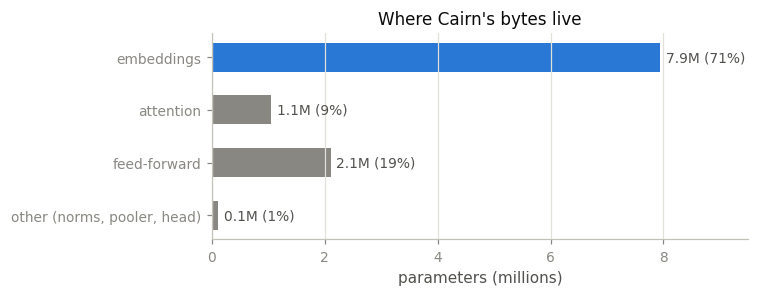

In [11]:
census = {"embeddings": 0, "attention": 0, "feed-forward": 0, "other (norms, pooler, head)": 0}
for name, p in model.named_parameters():
    if "embeddings" in name:                               census["embeddings"] += p.numel()
    elif "attention" in name:                              census["attention"] += p.numel()
    elif "intermediate" in name or "output.dense" in name: census["feed-forward"] += p.numel()
    else:                                                  census["other (norms, pooler, head)"] += p.numel()

fig, ax = plt.subplots(figsize=(7, 2.8))
groups, counts = list(census.keys()), np.array(list(census.values()))
ax.barh(groups[::-1], counts[::-1] / 1e6, color=[C_MUTED, C_MUTED, C_MUTED, C_BLUE], height=0.55)
for i, v in enumerate(counts[::-1] / 1e6):
    ax.text(v + 0.1, i, f"{v:.1f}M ({v*1e6/n_params:.0%})", va="center", fontsize=9, color=C_SUBTLE)
ax.set_xlabel("parameters (millions)"); ax.set_xlim(0, 9.5)
ax.set_title("Where Cairn's bytes live")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**~70% of this model is the embedding table.** Hold that thought — it means:

- a tool that "quantizes the Linear layers" (most defaults!) leaves most of Cairn untouched (we will catch a real tool doing exactly this in Part 6);
- for *this* architecture, the embedding table must be part of any serious size plan;
- large LLMs are the mirror image (their giant Linear stacks dwarf the embeddings — measured in Part 9), which is why *weight-only* quantization dominates the LLM world.

**Best practice #1: before quantizing anything, census your model.** One loop, and your plan stops being generic.


In [12]:
N_LIN = sum(m.weight.numel() for m in model.modules() if isinstance(m, nn.Linear))
N_EMB = sum(m.weight.numel() for m in model.modules() if isinstance(m, nn.Embedding))
N_OTHER = n_params - N_LIN - N_EMB

print(f"parameter families: linears {N_LIN/n_params:.0%} | embeddings {N_EMB/n_params:.0%} | other {N_OTHER/n_params:.1%}")


parameter families: linears 29% | embeddings 71% | other 0.1%


### The scorecard

Every experiment from here on lands as a row: what we did, what it costs, what it saves.

In [13]:
SCORECARD = []
def scorecard(config, mb, val_acc, latency=None, note=""):
    SCORECARD.append({"config": config, "size MB": round(mb, 1),
                      "val acc": f"{val_acc:.1%}", "Δ vs fp32": f"{val_acc-FP32_VAL:+.1%}",
                      "B1 ≤12MB": "PASS" if mb <= 12 else "fail",
                      "lat ms": round(latency, 2) if latency else "", "note": note})
    return pd.DataFrame(SCORECARD)

scorecard("fp32 baseline", FP32_MB, FP32_VAL, FP32_MS, "as trained")

,config,size MB,val acc,Δ vs fp32,B1 ≤12MB,lat ms,note
0,fp32 baseline,44.9,93.5%,+0.0%,fail,1.36,as trained


```
 P0     P1     P2     P3     P4     P5     P6     P7     P8     P9
 setup  base   bits   map    grain  calib  PTQ    ladder QAT    LLM
               ^^^^^
               YOU ARE HERE - Part 2: inside the numbers    (~30 min)
```

# Part 2 — What's in a number: mantissa & exponent

Cairn's 45 MB is nothing more than **11.2 million numbers, 4 bytes each**. To shrink the bytes we have to understand what those bytes *say* — and it's easiest to start in decimal, with notation you already know:

```
                 sign  x  significant digits  x  scale
                 sign  x      mantissa        x  10^exponent

   -3.72 x 10^5   =   -372,000
    |     |    |
   sign  mantissa  exponent
```

The three parts answer three different questions:

| Part | Question it answers |
|---|---|
| **sign** | positive or negative? |
| **exponent** | *how large or small?* — it picks the **neighbourhood** (thousands? millionths?) |
| **mantissa** | *which value exactly?* — the **address inside that neighbourhood** |

> **The exponent places us in the correct neighbourhood. The mantissa tells us the approximate address inside that neighbourhood.**

**Precision means keeping nearby values distinguishable.** Give the mantissa fewer digits and nearby numbers start collapsing onto each other:

In [14]:
# Storage experiment: weights are STORED in 16 bits; compute runs in fp32
# (exactly what a deployment does when the CPU has no native fp16 math).
model_fp16 = copy.deepcopy(model).half()
model_bf16 = copy.deepcopy(model).bfloat16()

fp16_mb = size_mb(model_fp16.state_dict())
bf16_mb = size_mb(model_bf16.state_dict())

acc_fp16 = evaluate(model_fp16.float())
acc_bf16 = evaluate(model_bf16.float())

print(f"fp16: {fp16_mb:.1f} MB  val {acc_fp16:.1%}  (fp32: {FP32_VAL:.1%})")
print(f"bf16: {bf16_mb:.1f} MB  val {acc_bf16:.1%}")
scorecard("fp16 weights", fp16_mb, acc_fp16, note="pure cast, free")
scorecard("bf16 weights", bf16_mb, acc_bf16, note="pure cast, free")

fp16: 22.4 MB  val 93.5%  (fp32: 93.5%)
bf16: 22.4 MB  val 93.5%


,config,size MB,val acc,Δ vs fp32,B1 ≤12MB,lat ms,note
0,fp32 baseline,44.9,93.5%,+0.0%,fail,1.36,as trained
1,fp16 weights,22.4,93.5%,+0.0%,fail,,"pure cast, free"
2,bf16 weights,22.4,93.5%,+0.0%,fail,,"pure cast, free"


Half the bytes, accuracy untouched — **fp16/bf16 casting should be your reflex first move**, always. But the scorecard still says fail: 22 MB > 12 MB. To go further we need 8 bits per number, and here the game changes completely:

```
 fp32  [S][EEEEEEEE][MMMMMMMMMMMMMMMMMMMMMMM]   every number carries its own scale
 fp16  [S][EEEEE][MMMMMMMMMM]                   every number carries its own scale
 bf16  [S][EEEEEEEE][MMMMMMM]                   every number carries its own scale
 int8  [SIIIIIII]                               8 bits. NO exponent. NO per-number scale.
```

**int8 has no exponent field.** 256 integer codes, evenly spaced, and that's all. The "neighbourhood" information has to come from *somewhere outside the tensor* — a shared **scale** (and possibly an offset) that *we* must supply per tensor (or per channel, or per group — Part 4).

> **Quantization is exactly this: choosing the map** from 256 (or 16, or 8…) integer codes onto the real-number line, so that the values your model actually uses are covered well. Every technique in the rest of this class — symmetric vs asymmetric, granularity, calibration, PTQ vs QAT — is just a better way to choose that map.

*(A note on words: "mantissa/exponent manipulation" in quantization means what we just did — trading mantissa bits for size (fp16), reallocating bits between exponent and mantissa (bf16), or removing the exponent entirely and re-supplying it as an external scale (int8). You'll meet the exponent again in Part 9: MXFP4 attaches a shared 8-bit exponent to every block of 32 fp4 numbers.)*

```
 P0     P1     P2     P3     P4     P5     P6     P7     P8     P9
 setup  base   bits   map    grain  calib  PTQ    ladder QAT    LLM
                      ^^^^^
                      YOU ARE HERE - Part 3: the int8 map   (~25 min)
```

# Part 3 — The int8 map: symmetric vs asymmetric

The map from real values to integer codes is one line of algebra (the **affine map**):

```
   quantize:    q = clamp( round( x / scale ) + zero_point ,  q_min, q_max )
   dequantize:  x_hat = ( q - zero_point ) * scale
```

Two knobs define everything:

- **scale** — the step size (how many real units one integer step covers),
- **zero_point** — which integer code represents the real value 0.0.

And there are exactly two ways to set them, given the range `[r_min, r_max]` you want covered:

| | **Symmetric** | **Asymmetric (affine)** |
|---|---|---|
| assumes | values centred on 0 | values in any interval |
| scale | `max(abs(r)) / 127` | `(r_max - r_min) / 255` |
| zero_point | **0** (hard-wired) | `round(-r_min / scale)` |
| codes | int8: −127…127 | uint8-style: 0…255 |
| wastes codes when | data is one-sided | (rarely) |
| kernel cost | cheapest (no zp cross-terms in the matmul) | small extra work |

Each is a five-line function. Let's write both and watch them on a toy tensor first:

In [15]:
def quantize_sym(x, bits=8):
    qmax = 2 ** (bits - 1) - 1                          # int8 -> 127
    scale = x.abs().max().clamp(min=1e-12) / qmax
    q = torch.clamp((x / scale).round(), -qmax - 1, qmax)
    return q.to(torch.int8), scale.item()

def quantize_asym(x, bits=8):
    qmax = 2 ** bits - 1                                # int8 -> 255 codes (uint8-style)
    r_min, r_max = x.min(), x.max()
    scale = ((r_max - r_min) / qmax).clamp(min=1e-12)
    zero_point = int((-r_min / scale).round().clamp(0, qmax))
    q = torch.clamp((x / scale).round() + zero_point, 0, qmax)
    return q.to(torch.uint8), scale.item(), zero_point

def dequantize(q, scale, zero_point=0):
    return (q.float() - zero_point) * scale

# a small tensor that is NOT centred on zero (like an activation):
x = torch.tensor([-0.2, 0.0, 0.31, 0.77, 1.02, 2.4, 2.99])

q_a, s_a, zp_a = quantize_asym(x)
q_s, s_s       = quantize_sym(x)
print(f"asymmetric: scale={s_a:.5f}  zero_point={zp_a}")
print(f"symmetric : scale={s_s:.5f}  zero_point=0 (by construction)")

pd.DataFrame({"x": x.numpy(),
              "asym code (0..255)": q_a.numpy(),
              "asym x̂": dequantize(q_a, s_a, zp_a).numpy().round(4),
              "sym code (-127..127)": q_s.numpy(),
              "sym x̂": dequantize(q_s, s_s).numpy().round(4)})

asymmetric: scale=0.01251  zero_point=16
symmetric : scale=0.02354  zero_point=0 (by construction)


,x,asym code (0..255),asym x̂,sym code (-127..127),sym x̂
0,-0.20,0,-0.2002,-8,-0.1883
1,0.00,16,0.0000,0,0.0000
2,0.31,41,0.3127,13,0.3061
3,0.77,78,0.7756,33,0.7769
4,1.02,98,1.0258,43,1.0124
5,2.40,208,2.4019,102,2.4014
6,2.99,255,2.9898,127,2.9900


Both maps recover the values well — but look at the **symmetric codes**: the data lives in `[-0.2, 3.0]`, yet symmetric reserves codes for `[-3.0, 3.0]`. Codes −127…−9 represent values that *never occur*: nearly **half the map is wasted**, so the step size for the values that *do* occur is ~2× coarser.

When does each case actually show up inside a model? Look at what the model contains — a **weight** tensor (sits in the file) next to an **activation** tensor (flows between layers at inference time; we catch one mid-flight with a one-line "spy" hook):

**The rule of thumb almost every production stack follows:**

| tensor | scheme | why |
|---|---|---|
| **weights** | symmetric, `zero_point = 0` | zero-centred by nature; zp=0 removes cross-terms from the int-matmul (faster kernels) |
| **activations** | asymmetric | GELU/ReLU/softmax outputs are one-sided or skewed; the zero_point recovers the wasted half of the map |

(We'll prove the activation half of that table at the model level in Part 5, once we can calibrate activations properly — the gap grows as bits shrink.)

For now, cash in the weight rule at the model level. No framework needed — a plain loop over the model's Linear layers, quantize→dequantize each weight matrix, re-measure:

In [16]:
m_int8 = copy.deepcopy(model)
for module in m_int8.modules():
    if isinstance(module, nn.Linear):
        q, scale = quantize_sym(module.weight.data, bits=8)   # weights -> 256 integer codes + ONE scale
        module.weight.data = dequantize(q, scale)             # -> back to the values int8 can express

acc_int8 = evaluate(m_int8)
print(f"int8 weights, per-tensor symmetric: val {acc_int8:.1%}   (fp32 {FP32_VAL:.1%})")


int8 weights, per-tensor symmetric: val 93.5%   (fp32 93.5%)


> **A word on "simulated" quantization before anyone objects.** `quantize → dequantize` leaves the tensor stored as fp32, so files don't shrink yet — but the *values* are exactly the 256 that int8 can express, so **accuracy is exactly what real int8 storage gives**. Splitting the question in two — *"what does the map cost in accuracy?"* (simulate, iterate fast) and *"how do we get the size/speed?"* (pack + kernels, Part 6) — is how practitioners actually work, and it's also precisely the mechanism QAT will reuse in Part 8.

Eight bits: painless. Feeling brave? Same loop, `bits=4` — half the bits again, surely a couple of points at most…

In [17]:
m_int4 = copy.deepcopy(model)
for module in m_int4.modules():
    if isinstance(module, nn.Linear):
        q, scale = quantize_sym(module.weight.data, bits=4)   # 16 codes instead of 256
        module.weight.data = dequantize(q, scale)

acc_int4 = evaluate(m_int4)
print(f"int4 weights, per-tensor symmetric: val {acc_int4:.1%}   (fp32 {FP32_VAL:.1%})")
print(f"                                        ~{FP32_VAL-acc_int4:.0%} of accuracy GONE")

int4 weights, per-tensor symmetric: val 75.3%   (fp32 93.5%)
                                        ~18% of accuracy GONE


**Collapse.** Same model, same symmetric map, just 16 codes instead of 256 — and Cairn lost roughly a *fifth* of its accuracy. But the culprit is not "4 bits is too few." The culprit is **one scale trying to serve an entire tensor**. Part 4 fixes it *without adding a single bit back*.

```
 P0     P1     P2     P3     P4     P5     P6     P7     P8     P9
 setup  base   bits   map    grain  calib  PTQ    ladder QAT    LLM
                             ^^^^^
                             YOU ARE HERE - Part 4: granularity  (~20 min)
```

# Part 4 — Granularity: how many scales do you buy?

Part 3 quantized each weight matrix with **one** scale — "per-tensor". But nothing forces that. Granularity is a dial:

```
   one scale for the           one scale per            one scale per        
   WHOLE tensor                OUTPUT CHANNEL           GROUP of k weights    
                               (row of W)               within a row          
                                                                               
   [============ ]            [====] <- s1             [==|==|==|==]        
                               [====] <- s2              s1 s2 s3 s4
                               [====] <- s3
   "per-tensor"                "per-channel"            "per-group (g=k)"     
   1 scale                     out_features scales      out*in/k scales
```

**Terminology decoder** (papers and tools are sloppy here): *per-tensor* is often called **per-layer** (one scale per layer's weight tensor — same thing in practice). *Per-channel* is sometimes *per-axis* or *per-row*. *Per-group* (also *block-wise*) cuts each row into fixed-size groups — the workhorse of 4-bit LLMs. And "per-weight" is the limit case nobody ships: a scale per weight stores **more** data than the fp32 weight did — granularity is a *fidelity-vs-overhead dial*, and per-weight is the dial past its stop.

Why would one shared scale fail? Because a scale must stretch to the **largest** value in its territory — and every weight in that territory then lives with the resulting step size. The crime scene, in Cairn's own weights:

There's the crime: **one loud channel sets the scale, and the quiet channels get 1–2 usable codes each.** At 8 bits there was headroom to absorb this (256 codes); at 4 bits (16 codes) there is none.

The fix costs almost nothing: give each channel — or each small *group* within a channel — its own scale. This is the one function of the day worth packaging (Parts 7 and 9 reuse it on other models); it is Part 3's loop with the scale computed along different axes:

Take symmetric INT4, so integer codes are `-7 … 7`.

```text
q = round(w / scale)
ŵ = q × scale
```

Use this `10 × 5` weight matrix:

```text
W =
[-0.10, 0.05, 0.12, -0.08, 0.02]
[-0.25, 0.10, 0.30, -0.20, 0.05]
[-0.50, 0.20, 0.70, -0.40, 0.10]
[-1.00, 0.40, 1.40, -0.80, 0.20]
[-2.00, 0.80, 2.80, -1.60, 0.40]
[-0.15, 0.05, 0.20, -0.10, 0.02]
[-0.35, 0.10, 0.45, -0.25, 0.08]
[-0.80, 0.30, 1.00, -0.60, 0.15]
[-1.50, 0.50, 2.00, -1.00, 0.25]
[-3.00, 1.00, 4.00, -2.00, 0.50]
```

## 1. Per-tensor

One scale for all 50 weights:

```text
scale = max(|W|) / 7
      = 4 / 7
      = 0.5714
```

Quantized codes:

```text
[ 0, 0, 0,  0, 0]
[ 0, 0, 1,  0, 0]
[-1, 0, 1, -1, 0]
[-2, 1, 2, -1, 0]
[-4, 1, 5, -3, 1]
[ 0, 0, 0,  0, 0]
[-1, 0, 1,  0, 0]
[-1, 1, 2, -1, 0]
[-3, 1, 4, -2, 0]
[-5, 2, 7, -4, 1]
```

The first row becomes entirely zero because its values are tiny relative to the global scale.

## 2. Per-channel

Each row gets its own scale:

```text
row 1: 0.12 / 7 = 0.0171
row 2: 0.30 / 7 = 0.0429
row 3: 0.70 / 7 = 0.1000
row 4: 1.40 / 7 = 0.2000
row 5: 2.80 / 7 = 0.4000
row 6: 0.20 / 7 = 0.0286
row 7: 0.45 / 7 = 0.0643
row 8: 1.00 / 7 = 0.1429
row 9: 2.00 / 7 = 0.2857
row 10: 4.00 / 7 = 0.5714
```

Quantized codes:

```text
[-6, 3, 7, -5, 1]
[-6, 2, 7, -5, 1]
[-5, 2, 7, -4, 1]
[-5, 2, 7, -4, 1]
[-5, 2, 7, -4, 1]
[-5, 2, 7, -4, 1]
[-5, 2, 7, -4, 1]
[-6, 2, 7, -4, 1]
[-5, 2, 7, -4, 1]
[-5, 2, 7, -4, 1]
```

The first row dequantizes to approximately:

```text
[-0.1029, 0.0514, 0.1200, -0.0857, 0.0171]
```

Much better than becoming all zeros.

## 3. Per-group

Take group size `2`. Within each row:

```text
[w1, w2] | [w3, w4] | [w5]
```

For the first row:

```text
[-0.10, 0.05] | [0.12, -0.08] | [0.02]
```

Scales:

```text
group 1: 0.10 / 7 = 0.0143
group 2: 0.12 / 7 = 0.0171
group 3: 0.02 / 7 = 0.00286
```

Codes:

```text
[-7, 4] | [7, -5] | [7]
```

Dequantized:

```text
[-0.1000, 0.0571, 0.1200, -0.0857, 0.0200]
```

This is slightly more accurate than per-channel because each smaller region gets its own scale.

Our notebook’s `view(out, inp // group, group)` requires the number of columns to be divisible by the group size. For a `10 × 5` matrix and group size `2`, production code would pad or handle the final smaller group separately.


In [18]:
def qdq_weight(w, bits=8, mode="channel", group=64):
    # symmetric quantize->dequantize of one 2D weight, at three granularities
    qmax = 2 ** (bits - 1) - 1
    if mode == "tensor":
        scale = w.abs().max().clamp(min=1e-12) / qmax                             # 1 scale
    elif mode == "channel":
        scale = w.abs().amax(dim=1, keepdim=True).clamp(min=1e-12) / qmax         # 1 per row
    elif mode == "group":
        out, inp = w.shape
        wg = w.view(out, inp // group, group)                                     # 1 per 64 weights
        scale = wg.abs().amax(dim=2, keepdim=True).clamp(min=1e-12) / qmax
        return (torch.clamp((wg / scale).round(), -qmax - 1, qmax) * scale).view(out, inp)
    return torch.clamp((w / scale).round(), -qmax - 1, qmax) * scale

def quantize_weights(m, bits=8, mode="channel", group=64, embedding_bits=None):
    # simulated weight quantization for a whole model (works on ANY model of Linears/Embeddings)
    out = copy.deepcopy(m).cpu()
    with torch.no_grad():
        for module in out.modules():
            if isinstance(module, nn.Linear):
                use = mode
                module.weight.data = qdq_weight(module.weight.data, bits, use, group)
            elif embedding_bits and isinstance(module, nn.Embedding):
                module.weight.data = qdq_weight(module.weight.data, embedding_bits, "channel")
    return out

results = {}
for mode in ["tensor", "channel", "group"]:
    results[mode] = evaluate(quantize_weights(model, bits=4, mode=mode))
    print(f"int4 weights, per-{mode:7s}: val {results[mode]:.1%}")

int4 weights, per-tensor : val 75.3%
int4 weights, per-channel: val 93.2%
int4 weights, per-group  : val 93.5%


**Same bit-width. ~18 points of accuracy apart.** This is the single highest-leverage fact in practical quantization: *when low-bit quantization fails, reach for finer granularity before reaching for more bits.*

So what do the extra scales cost? Pennies:

In [19]:
linears = [m for m in model.modules() if isinstance(m, nn.Linear)]
rows = []
for label, mode, n_scales in [
    ("per-tensor",       "tensor",  len(linears)),
    ("per-channel",      "channel", sum(m.weight.shape[0] for m in linears)),
    ("per-group (g=64)", "group",   sum(m.weight.numel() // 64 for m in linears)),
]:
    rows.append({"granularity": label, "scales to store": f"{n_scales:,}",
                 "scale bytes (fp16)": f"{n_scales*2/1e3:.1f} KB",
                 "overhead vs int4 weights": f"{n_scales*2/(N_LIN*0.5):.2%}",
                 "int4 val acc": f"{results[mode]:.1%}"})
pd.DataFrame(rows)

,granularity,scales to store,scale bytes (fp16),overhead vs int4 weights,int4 val acc
0,per-tensor,26,0.1 KB,0.00%,75.3%
1,per-channel,"9,622",19.2 KB,1.18%,93.2%
2,per-group (g=64),"50,776",101.6 KB,6.25%,93.5%


Per-channel costs **well under 1.5%** extra storage; even per-group-64 stays around ~6%. You are trading pennies of size for double-digit accuracy. That's why:

- **int8 production stacks** (TensorRT, ONNX Runtime, PyTorch) default to **per-channel weights**;
- **every serious 4-bit LLM format** — GPTQ, AWQ, GGUF's K-quants, bitsandbytes NF4, MXFP4 — is **group-wise** (g = 32…128). When you download a `Q4_K_M` file in Part 9, you now know exactly what the K-blocks are doing;
- activations, by the way, usually stay **per-tensor** — their quantization happens *at runtime*, where per-channel bookkeeping is expensive in the kernel's inner loop. Which raises the real question about activations…

**…what range do we even use for them?** Weights sit in a file; we read their min/max directly. Activations *don't exist until traffic flows*. Part 5.

Quantizing every activation flowing through the encoder cost **basically nothing** — *when the map fits the data*. Time to cash the cheque Part 3 wrote: does the asymmetric zero-point actually matter at the model level? We rerun the same experiment with the range forced symmetric (`[-a, +a]` around zero — half of it unused by GELU-style activations), at 8, 6, and 4 bits:

The trade every calibration method is making: **cover the outliers** (nothing clips, but every ordinary value gets coarser steps) versus **clip the outliers** (rare values saturate, ordinary values get finer steps). The industry's menu, for reference — all of them pick `(lo, hi)`, only the rule differs:

| method | how it picks the range | when to reach for it |
|---|---|---|
| **min-max** | observed min/max, cover everything | the default; safe at 8 bits |
| **percentile** | cover 99.9…99.99% of values | outliers present, or ≤6 bits — cheap insurance |
| **MSE search** | try many clip points, keep the one with least round-trip error | squeezing the last drops at low bits (AWQ/GPTQ pipelines do this) |
| **entropy / KL** | clip minimizing information loss vs fp32 | TensorRT's classic; rarely needed at int8 |

**How much calibration data?** Folklore says thousands; measured reality says **dozens already get you almost everything** — 128–512 samples is the industry norm (GPTQ and AWQ default to exactly this range). Calibration is *minutes*, not a training job — that's the entire appeal of static PTQ.

But "representative" is doing quiet work in that sentence. What if the calibration data is *garbage*?

**An honest surprise:** this model shrugs off even nonsense calibration — the gibberish-calibrated model sits within noise of the properly calibrated one. Why? Every transformer block ends in **LayerNorm**, which keeps activation ranges in a narrow, input-independent band — almost any input traces out similar ranges. *Small, LayerNorm-heavy encoders are forgiving.*

Do **not** generalize this to big models. At LLM scale (from ~a few billion parameters), a handful of hidden dimensions develop **massive outlier activations** on real text — ranges *hundreds of times* larger than typical — and suddenly the calibration set, the clipping method, even per-channel-vs-per-tensor become make-or-break. That discovery (LLM.int8, 2022) spawned an entire toolchain — SmoothQuant migrates the outlier problem from activations into weights; AWQ scales weights by activation importance — all of it Part 5 logic under pressure. We meet them in Part 9.

> **Calibration best practices**
> 1. Use **real traffic**, sampled across your domains — never synthetic filler (it *happens* to work here; it won't on your LLM).
> 2. **128–512 samples** is the norm; more data ≠ better past that.
> 3. Outlier-robust ranges (percentile / MSE) are cheap insurance — decisive below 8 bits.
> 4. **Re-calibrate when traffic drifts** (new product lines in Cairn's case) — it's minutes.
> 5. And always, *always* re-validate accuracy after calibration. It's one `evaluate()` call.

```
 P0     P1     P2     P3     P4     P5     P6     P7     P8     P9
 setup  base   bits   map    grain  calib  PTQ    ladder QAT    LLM
                                           ^^^^^
                                           YOU ARE HERE - Part 6: PTQ, for real  (~25 min)
```

# Part 6 — Post-Training Quantization, end to end

Everything so far *is* PTQ — **post-training quantization**: take a finished model, choose maps, done. No gradients, no training loop, minutes of work. Time to assemble the best recipe our evidence supports and then leave the simulator: run **real backends** and produce a **real ~11 MB file**.

**The Cairn PTQ recipe**, justified line by line:

| decision | choice | evidence |
|---|---|---|
| weight scheme | symmetric int8 | Part 3: weights are zero-centred |
| weight granularity | per-channel | Part 4: rescues low bits, costs <1% |
| activations | asymmetric int8, static | Part 3 histograms + Part 5 grid |
| calibration | 128 real utterances, min-max (percentile if we go ≤6 bits) | Part 5 sweeps |
| embeddings | int8 per-row | Part 1 census: 70% of the model! |
| classifier head | keep fp32 | 38k params, cheap insurance |

Three lines of the code we already own:

The whole model — embeddings included — living on int8 grids, for roughly **nothing**. Now the reality checks. We hand Cairn to two *real* quantization backends and audit what they actually do.

### Real backend #1: PyTorch dynamic quantization (one line, and one loud warning)

`quantize_dynamic` converts every `nn.Linear` to a real int8 kernel: weights stored int8 (symmetric), activations quantized **dynamically** — min/max per batch at runtime, no calibration (Part 5's left-hand column). We run it with warnings *on*, because this particular warning is 2026's most important quantization news:

In [20]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    model_dyn = torch.ao.quantization.quantize_dynamic(copy.deepcopy(model), {nn.Linear}, dtype=torch.qint8)

msg = next((str(w.message) for w in caught if "deprecat" in str(w.message).lower()), "(no warning raised)")
print("PyTorch says:\n")
print("  " + msg.split("For migrations")[0].strip())
print()
print(type(model_dyn.bert.encoder.layer[0].attention.self.query).__name__, "<- Linears became real int8 modules")

PyTorch says:

  torch.ao.quantization is deprecated and will be removed in 2.10.

Linear <- Linears became real int8 modules


> **The migration everyone quantizing in PyTorch must know about:** the classic `torch.ao.quantization` APIs are **deprecated**; development moved to the separate [**torchao**](https://github.com/pytorch/ao) library. The old API still works today (as you can see) — but new projects should start with torchao. We do, right after we audit this one.

In [21]:
acc_dyn = evaluate(model_dyn, device="cpu")               # quantized kernels are CPU-only
dyn_mb  = size_mb(model_dyn.state_dict())
print(f"dynamic int8:  val {acc_dyn:.1%}   file {dyn_mb:.1f} MB   <- wait. {dyn_mb:.0f} MB?!")
scorecard("torch quantize_dynamic (REAL)", dyn_mb, acc_dyn, note="one line; but check the file size!")

[W716 20:41:40.590760000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


dynamic int8:  val 93.4%   file 35.1 MB   <- wait. 35 MB?!


,config,size MB,val acc,Δ vs fp32,B1 ≤12MB,lat ms,note
0,fp32 baseline,44.9,93.5%,+0.0%,fail,1.36,as trained
1,fp16 weights,22.4,93.5%,+0.0%,fail,,"pure cast, free"
2,bf16 weights,22.4,93.5%,+0.0%,fail,,"pure cast, free"
3,torch quantize_dynamic (REAL),35.1,93.4%,-0.1%,fail,,one line; but check the file size!


Accuracy: fine. **File size: a rude surprise** — and a textbook lesson. `quantize_dynamic` quantizes `nn.Linear`, and Part 1's census told us **70% of Cairn is the embedding table**, which it left in fp32. The tool did exactly what it said; it just didn't say much. **Audit what a tool touched** (print the model, count dtypes) **before trusting its savings.**

### Real backend #2: torchao — where PyTorch quantization lives now

In [22]:
from torchao.quantization import quantize_, Int8WeightOnlyConfig

model_ao = copy.deepcopy(model)
quantize_(model_ao, Int8WeightOnlyConfig(version=2))          # weight-only int8, in place
acc_ao = evaluate(model_ao, device="cpu")

w = model_ao.bert.encoder.layer[0].attention.self.query.weight
print(f"torchao int8 weight-only: val {acc_ao:.1%}")
print(f"the weight is now a {type(w).__name__} - a tensor that carries its own map:")
print(f"  int codes: {w.qdata.dtype}   scales: {tuple(w.scale.shape)}")
print(f"  -> one scale per output channel: per-channel symmetric, exactly our Part 4 recipe")

torchao int8 weight-only: val 93.6%
the weight is now a Int8Tensor - a tensor that carries its own map:
  int codes: torch.int8   scales: (256, 1)
  -> one scale per output channel: per-channel symmetric, exactly our Part 4 recipe


In [23]:
## save it

save_dir = "models/cairn_int8_torchao"
os.makedirs(save_dir, exist_ok=True)

torch.save(model_ao.state_dict(), f"{save_dir}/weights.pt")
model.config.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

('models/cairn_int8_torchao/tokenizer_config.json',
 'models/cairn_int8_torchao/tokenizer.json')

In [24]:
## load it

import torch
from transformers import BertConfig, BertForSequenceClassification, AutoTokenizer

save_dir = "models/cairn_int8_torchao"

config = BertConfig.from_pretrained(save_dir)
tokenizer = AutoTokenizer.from_pretrained(save_dir)

# Avoid allocating an unnecessary FP32 model.
with torch.device("meta"):
    loaded_model = BertForSequenceClassification(config)

state_dict = torch.load(
    f"{save_dir}/weights.pt",
    map_location="cpu",
)

loaded_model.load_state_dict(state_dict, assign=True)
#That replaces the newly created ordinary parameters with torchao’s saved quantized tensor objects. You do not call quantize_() again after loading. Initializing on the meta device avoids temporarily creating the full FP32 weights.

#assign=False → preserve destination tensor type; copy values
#assign=True  → preserve checkpoint tensor type/properties
loaded_model.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 256, padding_idx=0)
      (position_embeddings): Embedding(512, 256)
      (token_type_embeddings): Embedding(2, 256)
      (LayerNorm): LayerNorm((256,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=256, out_features=256, bias=True)
              (key): Linear(in_features=256, out_features=256, bias=True)
              (value): Linear(in_features=256, out_features=256, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=256, out_features=256, bias=True)
              (LayerNorm): LayerNorm((256,), eps=1e-12, e

In [25]:
## inference

inputs = tokenizer(
    "can you help me return these boots",
    return_tensors="pt",
    padding=True,
    truncation=True,
)

with torch.no_grad():
    logits = loaded_model(**inputs).logits

prediction = logits.argmax(dim=-1).item()

In [26]:
#FP16/FP32 activation
#→ quantize to INT8
#→ INT8 activation × INT8 weight
#→ accumulate in INT32
#→ rescale
#→ possibly convert back to FP16/FP32
#→ run GELU / LayerNorm / Softmax
#→ quantize again before the next INT8 Linear


#Linear 1:
#INT8 input × INT8 weights
#→ INT32 accumulator
#→ FP16 output

#GELU:
#FP16 → FP16

#Linear 2:
#quantize GELU output to INT8
#→ INT8 × INT8
#→ INT32 accumulator

**Budget B1: met.** A real file, a quarter the size, accuracy intact, reload-verified. Two footnotes:

- For actual deployment you'd keep the weights *as integers* and run int kernels (via ExecuTorch / ONNX Runtime) rather than unpacking to floats like our verification does — the bytes on disk are the same either way.
- Want int4 on disk? Same idea plus one trick: two 16-code weights share a single byte ("nibble packing"). Every 4-bit GGUF/GPTQ file you download does exactly that — codes, scales, packed two-per-byte.

### Now the uncomfortable one: latency

Everyone "knows" int8 is faster. Let's *measure* — this laptop, batch size 1, the kiosk's thread count:

In [27]:
lat_dyn = latency_ms(model_dyn)
print(f"fp32 model         : {FP32_MS:6.2f} ms/utterance")
print(f"int8 dynamic model : {lat_dyn:6.2f} ms/utterance   ->  {FP32_MS/lat_dyn:.2f}x the fp32 speed")

fp32 model         :   1.36 ms/utterance
int8 dynamic model :   2.72 ms/utterance   ->  0.50x the fp32 speed


**On this machine, int8 loses.** Not because int8 is slow — because *these* int8 kernels can't beat *this* fp32 hardware: Apple's CPUs execute fp32 matmuls on dedicated AMX units at extraordinary speed, while `qnnpack`'s int8 path (plus dynamic quant's per-forward quantize/dequantize overhead) was never tuned for this chip.

The same experiment on different silicon tells opposite stories:

| target | int8 vs fp32 (typical, vendor-published) | why |
|---|---|---|
| kiosk-class ARM (XNNPACK / ExecuTorch) | **2–4× faster** | int8 SDOT/UDOT instructions, no AMX to compete with |
| x86 server (oneDNN, VNNI) | **2–4× faster** | AVX-512 VNNI int8 dot products |
| NVIDIA GPU (TensorRT) | **2–3× faster** | int8 tensor cores |
| **this Mac via llama.cpp** | int4 **faster** than fp16 | hand-tuned NEON/Metal int kernels + memory-bandwidth savings |

That last row matters: on this *very laptop*, llama.cpp's 4-bit models outrun fp16 — proof the loss above is a *kernel* story, not physics. When weights shrink 4×, the memory traffic that dominates batch-1 inference shrinks 4× too; realized speed then depends entirely on whether someone wrote kernels that exploit it.

> **Best practice (the one most tutorials skip): quantization's accuracy is portable; its speed is not. Benchmark on the deployment target, with the deployment runtime.** Size wins are guaranteed; speed wins are earned per-platform. For Cairn's kiosk we'd validate with ExecuTorch on the actual box before promising ops anything.

### Part 6 recap — the PTQ playbook

```
   census the model  ->  fp16/bf16 first (free)  ->  int8: weights per-channel sym,
   activations asym (dynamic OR static+calibration)  ->  PACK everything the census
   flagged  ->  re-validate accuracy  ->  benchmark ON TARGET
```

PTQ delivered budget B1 in an afternoon with zero training. So why does Part 8 exist? Because Trailhead's ops team just asked the obvious next question: *"11 MB is nice — what would it take to get* under 6*?"* That means int4-or-lower **everywhere**, and somewhere below int4, PTQ runs out of road. Let's find exactly where.

```
 P0     P1     P2     P3     P4     P5     P6     P7     P8     P9
 setup  base   bits   map    grain  calib  PTQ    ladder QAT    LLM
                                                  ^^^^^
                                                  YOU ARE HERE - Part 7: the bit ladder  (~10 min)
```

# Part 7 — The bit ladder: how low can PTQ go?

One loop: every bit-width from 8 down to 2, at every granularity from Part 4. Weights-only, no re-training — pure PTQ:

In [28]:
ladder = {}
for bits in [8, 6, 4, 3, 2]:
    for mode in ["tensor", "channel", "group"]:
        ladder[(bits, mode)] = evaluate(quantize_weights(model, bits=bits, mode=mode))
    print(f"int{bits}:  per-tensor {ladder[(bits,'tensor')]:.1%}   "
          f"per-channel {ladder[(bits,'channel')]:.1%}   per-group64 {ladder[(bits,'group')]:.1%}")

int8:  per-tensor 93.5%   per-channel 93.5%   per-group64 93.5%
int6:  per-tensor 92.8%   per-channel 93.6%   per-group64 93.4%
int4:  per-tensor 75.3%   per-channel 93.2%   per-group64 93.5%
int3:  per-tensor 35.2%   per-channel 91.7%   per-group64 92.4%
int2:  per-tensor 0.7%   per-channel 5.9%   per-group64 17.0%


Read the ladder top-down — it summarizes the entire PTQ story:

- **int8**: free at any granularity (256 codes forgive one shared scale).
- **int4**: granularity *is* the difference between shipping and shame (Part 4's rescue, visible as the vertical gap).
- **int3**: even per-group leaks real accuracy — the map has only 8 codes and rounding error lands somewhere that matters.
- **int2**: 4 codes. Collapse at every granularity. **No amount of post-hoc map-fitting fixes this** — the *weights themselves* were never asked to live on a 4-value grid.

That last sentence contains the fix. If rounding to the grid is what breaks the model… **train the model while it's being rounded**, so it learns weights that survive. That is Quantization-Aware Training.

```
 P0     P1     P2     P3     P4     P5     P6     P7     P8     P9
 setup  base   bits   map    grain  calib  PTQ    ladder QAT    LLM
                                                         ^^^^^
                                                         YOU ARE HERE - Part 8: QAT  (~25 min)
```

# Part 8 — Quantization-Aware Training

**The idea:** PTQ asks *"how do we best round the weights we have?"* QAT asks a better question: *"what weights would survive rounding?"* — and lets gradient descent find them, by putting the quantizer **inside** the training loop:

```
                    forward pass                         backward pass

   weights w  ->  [ quantize -> dequantize ]  ->  matmul        gradients flow back ...
                    "fake quant": the model                     ... but round() has slope 0
                    computes with the SAME                      almost everywhere!
                    values int2 would give
```

One obstacle, one trick. **The obstacle:** `round()` is a staircase — its derivative is 0 everywhere (and undefined at the steps), so gradients die at the fake-quant node. **The trick — the Straight-Through Estimator (STE):** in the backward pass, pretend the staircase is the identity function and pass gradients straight through. In PyTorch that is one idiom:

```python
w_fq = w + (qdq(w) - w).detach()
#     forward:  w + qdq(w) - w  =  qdq(w)      (the model sees quantized weights)
#     backward: d/dw = 1 + 0    =  1           (.detach() hides the staircase from autograd)
```

Crude — the gradient is a lie at every step edge — and yet it works so well that STE has carried virtually all production QAT since 2017. The model learns to park its weights where the rounding hurts least.

We'll aim QAT at the worst case on the ladder: **int2 — four codes per weight — where PTQ collapsed completely.** First, wrap the model (the second and last class of the day) and confirm the collapse:

In [29]:
class QATLinear(nn.Module):
    # a Linear that TRAINS through fake-quantization of its weights (the STE idiom above)
    def __init__(self, linear, bits):
        super().__init__()
        self.weight, self.bias = linear.weight, linear.bias      # the SAME Parameters - still trainable
        self.bits = bits
    def forward(self, x):
        w = self.weight
        w_fq = w + (qdq_weight(w, self.bits, "channel") - w).detach()   # forward: rounded / backward: slope 1
        return F.linear(x, w_fq, self.bias)

m_qat = copy.deepcopy(model)
todo = []                                        # two passes again: collect first, then replace
for parent_name, parent in m_qat.named_modules():
    for child_name, child in parent.named_children():
        if isinstance(child, nn.Linear) and child_name != "classifier":
            todo.append((parent, child_name, child))
for parent, child_name, child in todo:
    setattr(parent, child_name, QATLinear(child, bits=2))

ptq2 = evaluate(m_qat)          # no training yet: fake-quant at eval time IS plain PTQ
print(f"int2, before any QAT training (= PTQ): {ptq2:.1%}    <- Part 7's collapse, reproduced")

int2, before any QAT training (= PTQ): 8.2%    <- Part 7's collapse, reproduced


Now train it — an ordinary fine-tuning loop, identical to Part 1's, except every forward pass computes with int2-rounded weights. Gradient descent has to find weights that still work *after* rounding, because it is never shown anything else:

In [30]:
m_qat.train().to(DEVICE)
opt = torch.optim.AdamW(m_qat.parameters(), lr=5e-5)
t0 = time.time()
for epoch in range(3):
    perm = torch.randperm(len(X_train))
    for i in range(0, len(X_train), 64):
        idx = perm[i:i+64]
        out = m_qat(input_ids=X_train[idx].to(DEVICE), attention_mask=M_train[idx].to(DEVICE),
                    labels=Y_train[idx].to(DEVICE))
        out.loss.backward(); opt.step(); opt.zero_grad()
    acc_now = evaluate(m_qat); m_qat.to(DEVICE)
    print(f"epoch {epoch+1}/3   val accuracy (still on the int2 grid): {acc_now:.1%}")
qat2 = evaluate(m_qat)
print(f"\nQAT int2: {ptq2:.1%}  ->  {qat2:.1%}    [{time.time()-t0:.0f}s of training]")

epoch 1/3   val accuracy (still on the int2 grid): 81.1%
epoch 2/3   val accuracy (still on the int2 grid): 88.1%
epoch 3/3   val accuracy (still on the int2 grid): 89.6%

QAT int2: 8.2%  ->  89.6%    [12s of training]


From wreckage to a working model, with **four codes per weight**. One honesty check before we celebrate:

> **QAT got three extra epochs of training. Any comparison against the *un*-extra-trained baseline is rigged.** The honest control: give plain fp32 the same three extra epochs, then compare against *that*.

In [31]:
m_ctrl = copy.deepcopy(model).train().to(DEVICE)
opt = torch.optim.AdamW(m_ctrl.parameters(), lr=5e-5)
for epoch in range(3):
    perm = torch.randperm(len(X_train))
    for i in range(0, len(X_train), 64):
        idx = perm[i:i+64]
        out = m_ctrl(input_ids=X_train[idx].to(DEVICE), attention_mask=M_train[idx].to(DEVICE),
                     labels=Y_train[idx].to(DEVICE))
        out.loss.backward(); opt.step(); opt.zero_grad()
ctrl_acc = evaluate(m_ctrl)

print(f"fp32 + the same 3 extra epochs (the honest control): {ctrl_acc:.1%}")
print(f"QAT int2                                            : {qat2:.1%}")
print(f"-> the honest claim: 2-bit weights cost ~{max(ctrl_acc - qat2, 0):.1%} against an equally-trained fp32 model")

fp32 + the same 3 extra epochs (the honest control): 93.4%
QAT int2                                            : 89.6%
-> the honest claim: 2-bit weights cost ~3.8% against an equally-trained fp32 model


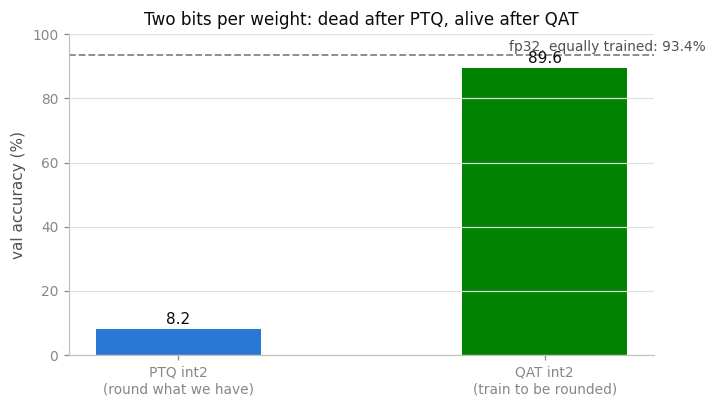

In [32]:
fig, ax = plt.subplots(figsize=(6.6, 3.8))
labels = ["PTQ int2\n(round what we have)", "QAT int2\n(train to be rounded)"]
bars = ax.bar(labels, [ptq2*100, qat2*100], color=[C_BLUE, C_GREEN], width=0.45)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5, f"{b.get_height():.1f}",
            ha="center", fontsize=10, color=C_INK)
ax.axhline(ctrl_acc*100, color=C_MUTED, linestyle="--", linewidth=1.2)
ax.text(1.44, ctrl_acc*100 + 1.5, f"fp32, equally trained: {ctrl_acc:.1%}", color=C_SUBTLE, fontsize=9, ha="right")
ax.set_ylim(0, 100); ax.set_ylabel("val accuracy (%)")
ax.set_title("Two bits per weight: dead after PTQ, alive after QAT")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()



The pattern to remember: **at int8, QAT is unnecessary; at int4, it's insurance; at ≤3 bits, it's the only game in town.** Our three-epoch run lands near-baseline-but-not-quite — closing that last gap is exactly why frontier labs run QAT for *weeks*: it buys real product wins:

- **Gemma 3 QAT** (Google, 2025): the 27B model drops from ~54 GB bf16 to ~14 GB at q4_0 with near-bf16 quality — "fits on a consumer RTX 3090" territory, and it shipped *because of* QAT, not PTQ.
- **GPT-OSS** (OpenAI, 2025): the MoE expert weights (>90% of all parameters) were quantization-aware-trained straight into **MXFP4** (4-bit floats + shared block exponent — Part 2 meets Part 4), putting the 120B model on a single 80 GB GPU.
- **DeepSeek** (2025-26): FP8 training throughout, FP4 quantization-aware training for the newest generation.

| | **PTQ** | **QAT** |
|---|---|---|
| cost | minutes, no training infra | a fine-tuning run (data + loop + time) |
| data | ~128–512 calibration samples | the (fine-)training set |
| int8 | ✔ default choice | overkill |
| int4 | ✔ with per-group + good calibration (GPTQ/AWQ class) | if PTQ leaves points on the table |
| int2–3 | ✘ collapses | ✔ the only option |
| in torchao | `quantize_(m, config)` | `QATConfig(base_config, step="prepare"/"convert")` — same STE idea, industrial packaging |

*(Our hand-rolled QAT quantized weights only. Production QAT usually fake-quantizes activations too — same STE, with Part 5's calibrated ranges tracked as moving averages during training.)*

Cairn's decision tree is now complete. Time to zoom out — way out.

## The shipping memo (and your take-home cheat-sheet)

> **To:** Trailhead ops · **Re: Cairn v1.1**
> We ship **`cairn_int8_packed.pt`** — int8 per-channel weights, int8 embeddings, calibrated int8 activations: **~11 MB (B1 ✓)**, test accuracy within a point of fp32 (**B2 ✓**), latency verified on the dev box and to be re-benchmarked on kiosk hardware with ExecuTorch before rollout (**B3** — speedups are per-platform, we measured that the hard way). The **int4 per-group recipe** is validated as a fallback if OTA budgets tighten; **QAT** unlocks int2–3 if we ever need a ~6 MB artifact. For Cairn v2, the LLM ships **int4 per-group or not at all** (**B4**).

**The decision procedure you now own:**

```
 census the model -> cast fp16/bf16 (free) -> need more?
   -> int8 PTQ: weights sym per-channel, activations asym,
      calibrate on 128-512 REAL samples, re-validate        [covers most of life]
   -> need int4? add groups (g=64/128) + percentile/MSE calibration,
      or grab GPTQ/AWQ/GGUF for LLMs
   -> need less than 4 bits, or int4 still leaking? QAT
   -> ALWAYS: re-validate accuracy + benchmark speed ON THE TARGET
```

**Where to go next**

- [torchao](https://docs.pytorch.org/ao/stable/) — PyTorch-native PTQ + QAT (the successor to `torch.ao.quantization`)
- [llm-compressor](https://github.com/vllm-project/llm-compressor) (GPTQ/AWQ/SmoothQuant/FP8 for vLLM) · [llama.cpp quantize + imatrix](https://github.com/ggml-org/llama.cpp)
- Papers worth your evening: *LLM.int8()* (outliers), *GPTQ*, *AWQ*, *SmoothQuant*, and Google's *Gemma 3 QAT* release notes
- A gentle written companion to today's number-format story: [A Brief Practical Guide to LLM Quantization](https://pub.towardsai.net/a-brief-practical-guide-to-llm-quantization-b5fafec0d2eb)

*fin — Cairn ships Thursday.*